In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.datasets import load_breast_cancer

In [2]:
database=load_breast_cancer()

In [3]:
database

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [4]:
data=database.data
target=database.target

In [5]:
scaled_data=StandardScaler().fit_transform(database.data)
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [19]:
gini_dt2=DecisionTreeClassifier(max_depth=2, criterion="gini", random_state=1)
gini_dt3=DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=1)
gini_dt4=DecisionTreeClassifier(max_depth=4, criterion="gini", random_state=1)
gini_dt5=DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=1)
gini_dt6=DecisionTreeClassifier(max_depth=6, criterion="gini", random_state=1)
gini_dt7=DecisionTreeClassifier(max_depth=7, criterion="gini", random_state=1)
gini_dt8=DecisionTreeClassifier(max_depth=8, criterion="gini", random_state=1)

In [21]:
en_dt2=DecisionTreeClassifier(max_depth=2, criterion="entropy", random_state=1)
en_dt3=DecisionTreeClassifier(max_depth=3, criterion="entropy", random_state=1)
en_dt4=DecisionTreeClassifier(max_depth=4, criterion="entropy", random_state=1)
en_dt5=DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=1)
en_dt6=DecisionTreeClassifier(max_depth=6, criterion="entropy", random_state=1)
en_dt7=DecisionTreeClassifier(max_depth=7, criterion="entropy", random_state=1)
en_dt8=DecisionTreeClassifier(max_depth=8, criterion="entropy", random_state=1)

In [22]:
X_train, X_test, y_train, y_test=train_test_split(data, target, test_size=0.2, random_state=1)

In [28]:
gini_models=[gini_dt2, gini_dt3, gini_dt4, gini_dt5, gini_dt6, gini_dt7, gini_dt8]
entropy_models=[en_dt2, en_dt3, en_dt4, en_dt5, en_dt6, en_dt7, en_dt8]

In [29]:
for model in gini_models:
    model.fit(X_train, y_train)

for model in entropy_models:
    model.fit(X_train, y_train)

gini_acc_scores=[]
gini_f1_scores=[]
entropy_acc_scores=[]
entropy_f1_scores=[]

for model in gini_models:
    y_predict=model.predict(X_test)
    gini_acc_scores.append(accuracy_score(y_test,y_predict))
    gini_f1_scores.append(f1_score(y_test,y_predict))

for model in entropy_models:
    y_predict=model.predict(X_test)
    entropy_acc_scores.append(accuracy_score(y_test,y_predict))
    entropy_f1_scores.append(f1_score(y_test, y_predict))

print(gini_acc_scores)
print(gini_f1_scores)
print(entropy_acc_scores)
print(entropy_f1_scores)


[0.8859649122807017, 0.9122807017543859, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315]
[0.912751677852349, 0.9315068493150684, 0.9594594594594594, 0.9594594594594594, 0.9594594594594594, 0.9594594594594594, 0.9594594594594594]
[0.868421052631579, 0.9122807017543859, 0.956140350877193, 0.956140350877193, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315]
[0.896551724137931, 0.9305555555555556, 0.9664429530201343, 0.9664429530201343, 0.96, 0.96, 0.96]


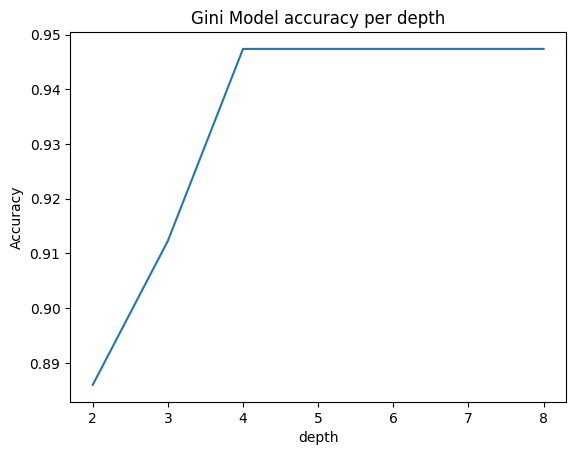

In [30]:
plt.plot(range(2,9), gini_acc_scores)
plt.title("Gini Model accuracy per depth")
plt.ylabel("Accuracy")
plt.xlabel("depth")
plt.show()

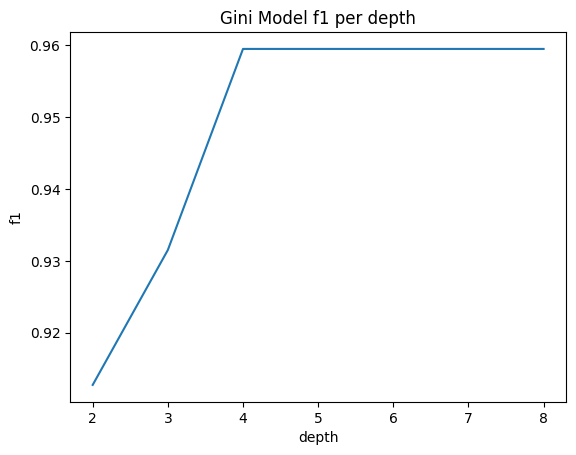

In [31]:
plt.plot(range(2,9), gini_f1_scores)
plt.title("Gini Model f1 per depth")
plt.ylabel("f1")
plt.xlabel("depth")
plt.show()

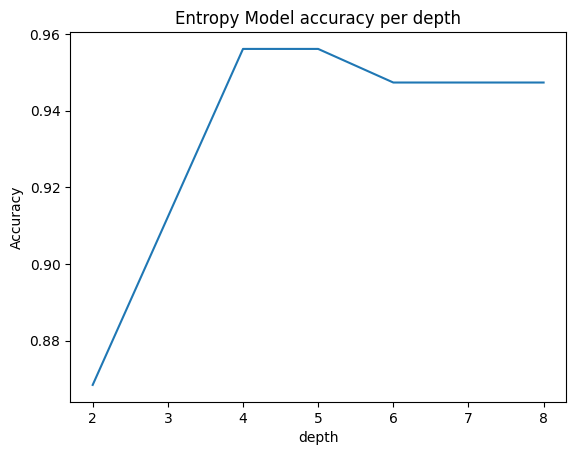

In [33]:
plt.plot(range(2,9), entropy_acc_scores)
plt.title("Entropy Model accuracy per depth")
plt.ylabel("Accuracy")
plt.xlabel("depth")
plt.show()

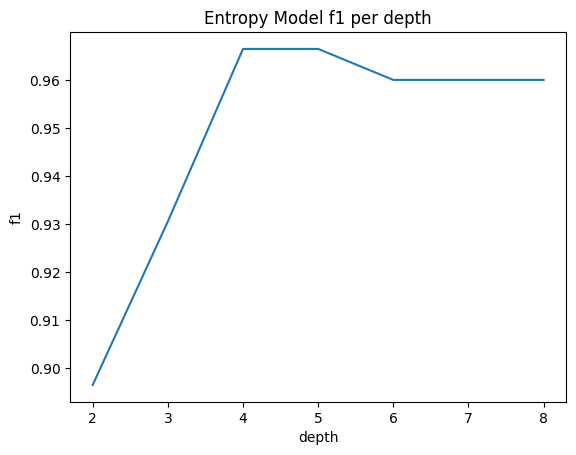

In [34]:
plt.plot(range(2,9), entropy_f1_scores)
plt.title("Entropy Model f1 per depth")
plt.ylabel("f1")
plt.xlabel("depth")
plt.show()

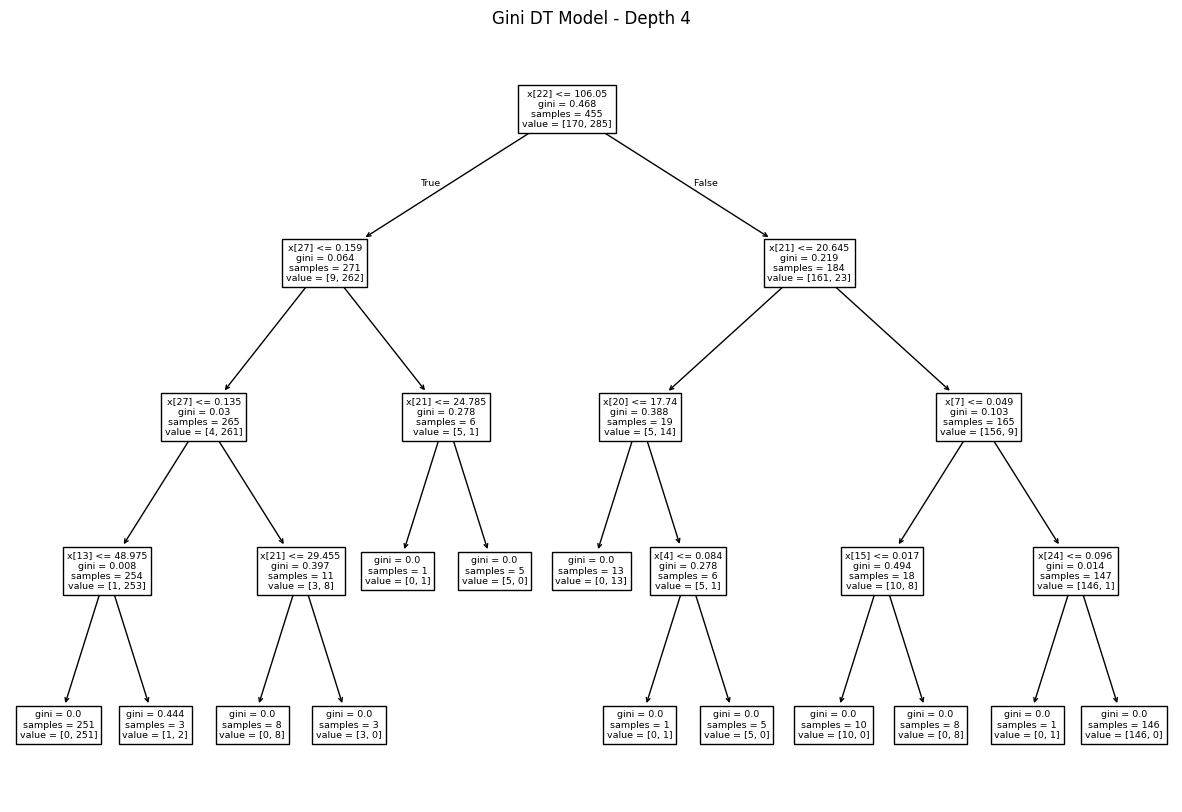

In [36]:
plt.figure(figsize=(15,10))
plot_tree(gini_dt4)
plt.title("Gini DT Model - Depth 4")
plt.show()

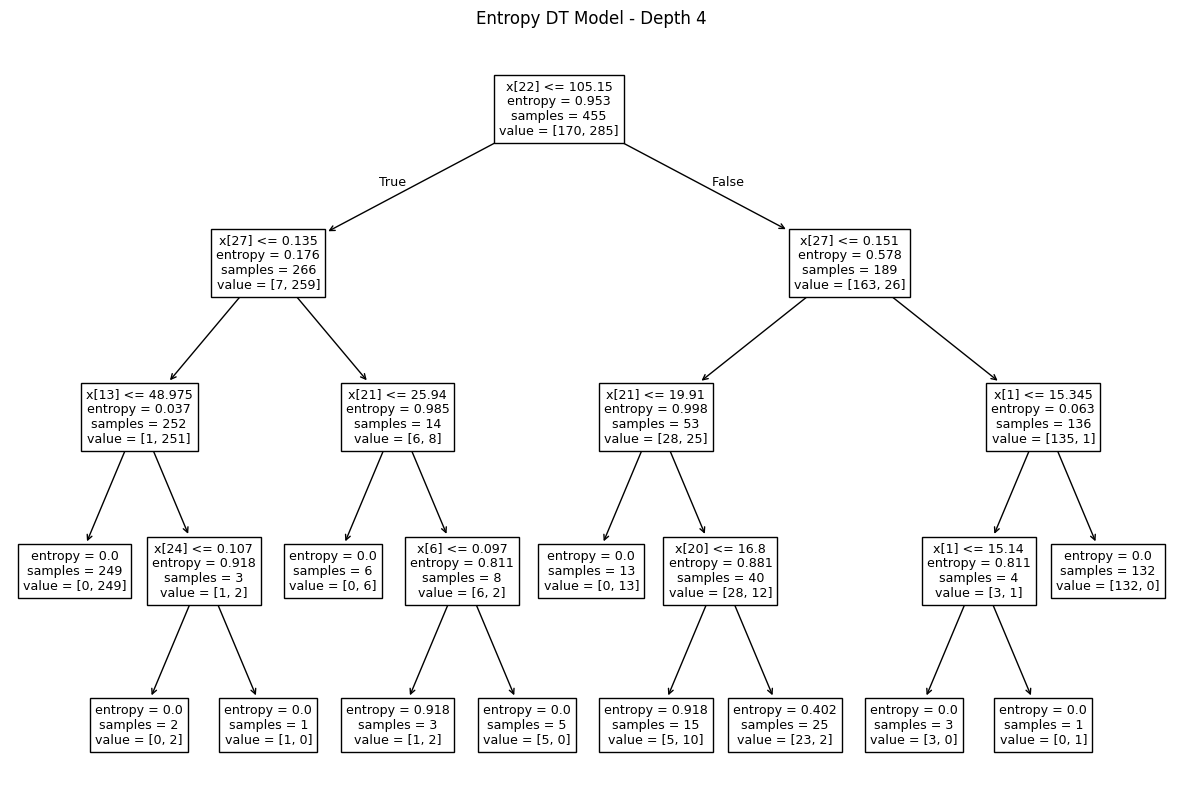

In [37]:
plt.figure(figsize=(15,10))
plot_tree(en_dt4)
plt.title("Entropy DT Model - Depth 4")
plt.show()